# Visualizaciones de resultados e impacto

Proyecto: Detección de Micro-paradas  
Materia: Inteligencia Artificial  

Este notebook presenta las visualizaciones de evaluación del modelo y una simulación del impacto del sistema en la reducción de downtime.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

sns.set_theme(style="whitegrid")

In [2]:
BASE = Path.cwd()

# Detectar si el notebook se ejecuta desde /notebook o desde la raíz del proyecto
if (BASE / "industrial_dataset.csv").exists():
    DATA_PATH = BASE / "industrial_dataset.csv"
    WEIGHTS_PATH = BASE / "pesos_modelo.npy"
elif (BASE / "notebook" / "industrial_dataset.csv").exists():
    DATA_PATH = BASE / "notebook" / "industrial_dataset.csv"
    WEIGHTS_PATH = BASE / "notebook" / "pesos_modelo.npy"
else:
    raise FileNotFoundError("No se encontró industrial_dataset.csv")

from pathlib import Path

OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta de salidas creada en:")
print(OUTPUT_DIR)

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente")
print("Ruta dataset:", DATA_PATH)
print("Ruta pesos:", WEIGHTS_PATH)
print("Forma del dataset:", df.shape)
print("Carpeta de salidas:", OUTPUT_DIR)

df.head()

Carpeta de salidas creada en:
C:\Users\yessi\Documents\8\IA\micro-stop-detection\notebook\outputs
Dataset cargado correctamente
Ruta dataset: C:\Users\yessi\Documents\8\IA\micro-stop-detection\notebook\industrial_dataset.csv
Ruta pesos: C:\Users\yessi\Documents\8\IA\micro-stop-detection\notebook\pesos_modelo.npy
Forma del dataset: (20000, 6)
Carpeta de salidas: C:\Users\yessi\Documents\8\IA\micro-stop-detection\notebook\outputs


,vibration,current,speed,temperature,micro_stop,cause
0,-0.009455,5.109608,98.336737,70.550623,0.0,0.0
1,-0.334556,5.391938,102.230699,70.261696,0.0,0.0
2,0.921980,4.316184,100.527441,70.061015,0.0,0.0
3,-0.122548,5.280542,97.052836,68.302402,0.0,0.0
4,-0.001837,4.640546,101.708254,69.281600,0.0,0.0


In [3]:
sensor_cols = ["vibration", "current", "speed", "temperature"]

# Rellenar valores faltantes
df[sensor_cols] = df[sensor_cols].interpolate(method="linear").bfill().ffill()

# Normalización Min-Max
df_norm = df.copy()

for col in sensor_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    df_norm[col] = (df[col] - col_min) / (col_max - col_min)

print("Datos limpios y normalizados")
print(df_norm.isnull().sum())

Datos limpios y normalizados
vibration      0
current        0
speed          0
temperature    0
micro_stop     0
cause          0
dtype: int64


In [4]:
def create_windows(df_normalizado, window_size=20):
    X = []
    y_detect = []
    y_cause = []

    features = df_normalizado[sensor_cols].values.astype(np.float32)
    labels_detect = df_normalizado["micro_stop"].values.astype(int)
    labels_cause = df_normalizado["cause"].values.astype(int)

    for i in range(len(features) - window_size):
        ventana = features[i : i + window_size]
        etiqueta = labels_detect[i + window_size]
        causa = labels_cause[i + window_size]

        X.append(ventana)
        y_detect.append(etiqueta)
        y_cause.append(causa)

    return np.array(X), np.array(y_detect), np.array(y_cause)


X, y_detect, y_cause = create_windows(df_norm, window_size=20)

print("Ventanas creadas correctamente")
print("X:", X.shape)
print("y_detect:", y_detect.shape)
print("y_cause:", y_cause.shape)

Ventanas creadas correctamente
X: (19980, 20, 4)
y_detect: (19980,)
y_cause: (19980,)


In [5]:
def split_dataset(X, y_detect, y_cause):
    total = len(X)

    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    X_train = X[:train_end]
    X_val = X[train_end:val_end]
    X_test = X[val_end:]

    y_train_detect = y_detect[:train_end]
    y_val_detect = y_detect[train_end:val_end]
    y_test_detect = y_detect[val_end:]

    y_train_cause = y_cause[:train_end]
    y_val_cause = y_cause[train_end:val_end]
    y_test_cause = y_cause[val_end:]

    return (
        X_train, X_val, X_test,
        y_train_detect, y_val_detect, y_test_detect,
        y_train_cause, y_val_cause, y_test_cause
    )


(
    X_train, X_val, X_test,
    y_train_detect, y_val_detect, y_test_detect,
    y_train_cause, y_val_cause, y_test_cause
) = split_dataset(X, y_detect, y_cause)

print("Datos separados correctamente")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Micro-paradas en test:", int(y_test_detect.sum()))

Datos separados correctamente
Train: (13986, 20, 4)
Validation: (2997, 20, 4)
Test: (2997, 20, 4)
Micro-paradas en test: 8


In [6]:
HIDDEN_SIZE = 32

np.random.seed(99)

scale_x = np.sqrt(2.0 / 4)
scale_h = np.sqrt(2.0 / HIDDEN_SIZE)

W_x_rnn = np.random.randn(4, HIDDEN_SIZE).astype(np.float32) * scale_x
W_h_rnn = np.random.randn(HIDDEN_SIZE, HIDDEN_SIZE).astype(np.float32) * scale_h * 0.1
b_rnn = np.zeros(HIDDEN_SIZE, dtype=np.float32)

def extract_context(X_batch):
    batch, window_size, n_features = X_batch.shape
    h = np.zeros((batch, HIDDEN_SIZE), dtype=np.float32)

    for t in range(window_size):
        x_t = X_batch[:, t, :]
        h = np.tanh(x_t @ W_x_rnn + h @ W_h_rnn + b_rnn)

    return h


print("Extractor de contexto reconstruido correctamente")

Extractor de contexto reconstruido correctamente


In [7]:
class DetectionHead:
    def __init__(self, input_size):
        self.W = np.zeros((input_size, 1), dtype=np.float32)
        self.b = np.zeros((1, 1), dtype=np.float32)

    @staticmethod
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, h):
        z = h @ self.W + self.b
        return self.sigmoid(z).squeeze()


class ClassificationHead:
    def __init__(self, input_size, n_classes=5):
        self.W = np.zeros((input_size, n_classes), dtype=np.float32)
        self.b = np.zeros((1, n_classes), dtype=np.float32)

    @staticmethod
    def softmax(z):
        z_shifted = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def forward(self, h):
        z = h @ self.W + self.b
        return self.softmax(z)


print("Clases del modelo cargadas correctamente")

Clases del modelo cargadas correctamente


In [8]:
pesos = np.load(WEIGHTS_PATH, allow_pickle=True).item()

det_head = DetectionHead(input_size=HIDDEN_SIZE)
cls_head = ClassificationHead(input_size=HIDDEN_SIZE, n_classes=5)

det_head.W = pesos["det_W"]
det_head.b = pesos["det_b"]

cls_head.W = pesos["cls_W"]
cls_head.b = pesos["cls_b"]

print("Pesos del modelo cargados correctamente")

Pesos del modelo cargados correctamente


In [9]:
UMBRAL = 0.4

h_test = extract_context(X_test)

probs_det = det_head.forward(h_test)
pred_det = (probs_det >= UMBRAL).astype(int)

# Solo se evalúa causa en las muestras donde realmente hubo micro-parada
mask_micro = y_test_detect == 1

probs_causa = cls_head.forward(h_test[mask_micro])

# Tomamos solo clases 1 a 4 porque la clase 0 significa normal
pred_causa = probs_causa[:, 1:5].argmax(axis=1) + 1
y_causa_real = y_test_cause[mask_micro].astype(int)

print("Predicciones generadas correctamente")
print("Micro-paradas reales en test:", int(y_test_detect.sum()))
print("Micro-paradas detectadas por el modelo:", int(pred_det.sum()))

Predicciones generadas correctamente
Micro-paradas reales en test: 8
Micro-paradas detectadas por el modelo: 45


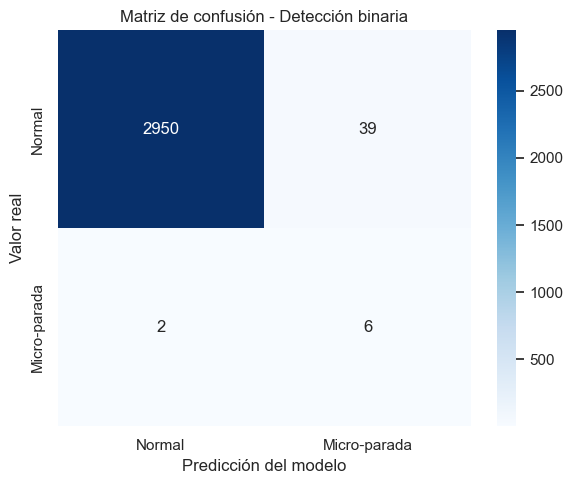

In [10]:
cm_det = confusion_matrix(y_test_detect, pred_det, labels=[0, 1])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_det,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Micro-parada"],
    yticklabels=["Normal", "Micro-parada"]
)

plt.title("Matriz de confusión - Detección binaria")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_matriz_confusion_db.png", dpi=300, bbox_inches="tight")
plt.show()

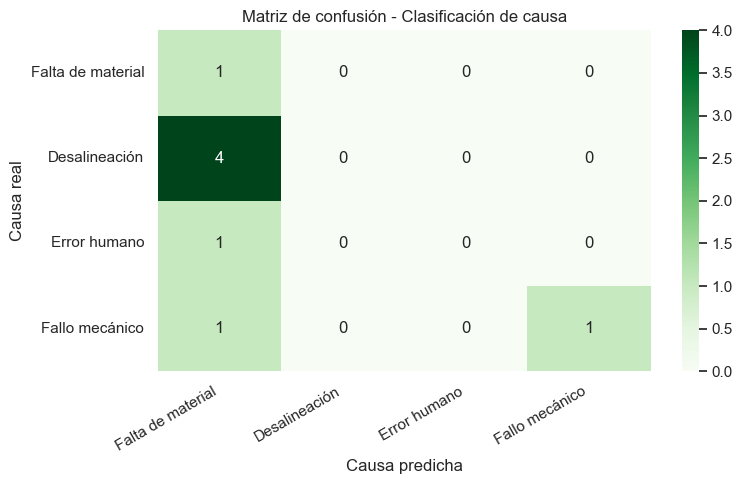

In [11]:
causas = {
    1: "Falta de material",
    2: "Desalineación",
    3: "Error humano",
    4: "Fallo mecánico"
}

labels_causas = [1, 2, 3, 4]
nombres_causas = [causas[i] for i in labels_causas]

cm_causa = confusion_matrix(
    y_causa_real,
    pred_causa,
    labels=labels_causas
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    cm_causa,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=nombres_causas,
    yticklabels=nombres_causas
)

plt.title("Matriz de confusión - Clasificación de causa")
plt.xlabel("Causa predicha")
plt.ylabel("Causa real")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_matriz_confusion_cc.png", dpi=300, bbox_inches="tight")
plt.show()

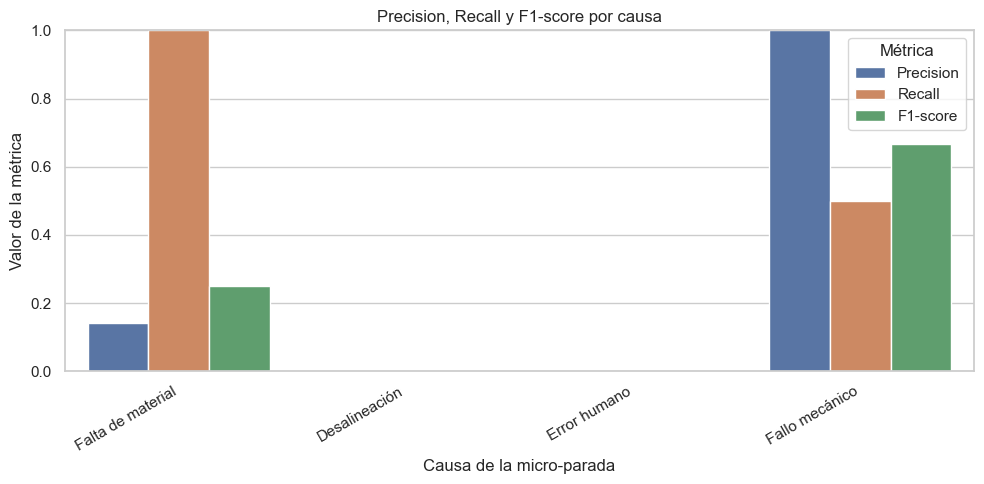

,Causa,Precision,Recall,F1-score
0,Falta de material,0.142857,1.0,0.250000
1,Desalineación,0.000000,0.0,0.000000
2,Error humano,0.000000,0.0,0.000000
3,Fallo mecánico,1.000000,0.5,0.666667


In [12]:
reporte = classification_report(
    y_causa_real,
    pred_causa,
    labels=labels_causas,
    target_names=nombres_causas,
    output_dict=True,
    zero_division=0
)

metricas = []

for causa in nombres_causas:
    metricas.append({
        "Causa": causa,
        "Precision": reporte[causa]["precision"],
        "Recall": reporte[causa]["recall"],
        "F1-score": reporte[causa]["f1-score"]
    })

df_metricas = pd.DataFrame(metricas)

df_metricas_melt = df_metricas.melt(
    id_vars="Causa",
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_metricas_melt,
    x="Causa",
    y="Valor",
    hue="Métrica"
)

plt.title("Precision, Recall y F1-score por causa")
plt.xlabel("Causa de la micro-parada")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Métrica")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_grafica.png", dpi=300, bbox_inches="tight")
plt.show()

df_metricas

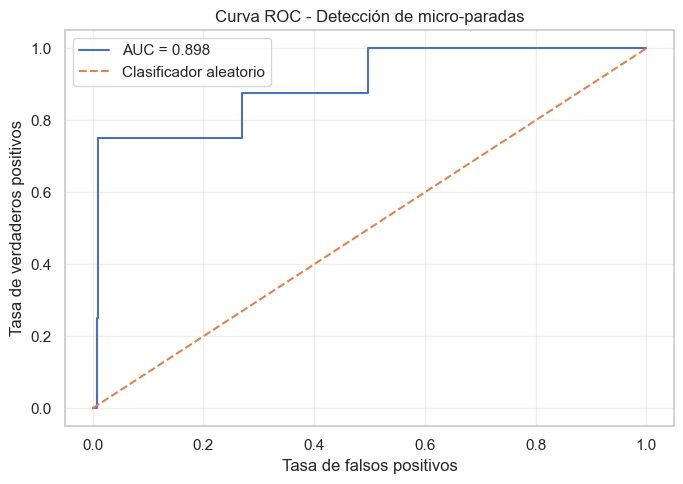

AUC obtenido: 0.898


In [13]:
fpr, tpr, thresholds = roc_curve(y_test_detect, probs_det)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.title("Curva ROC - Detección de micro-paradas")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_curva_roc.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC obtenido: {roc_auc:.3f}")

In [14]:
def calcular_anticipaciones(y_real, y_pred, max_anticipacion=20):
    eventos_reales = np.where(y_real == 1)[0]
    predicciones_positivas = np.where(y_pred == 1)[0]

    anticipaciones = []

    for evento in eventos_reales:
        candidatos = predicciones_positivas[
            (predicciones_positivas >= evento - max_anticipacion) &
            (predicciones_positivas <= evento)
        ]

        if len(candidatos) > 0:
            primera_alerta = candidatos[0]
            anticipacion = evento - primera_alerta
            anticipaciones.append(anticipacion)

    return np.array(anticipaciones)


anticipaciones = calcular_anticipaciones(
    y_test_detect,
    pred_det,
    max_anticipacion=20
)

print("Micro-paradas anticipadas:", len(anticipaciones))

if len(anticipaciones) > 0:
    print("Anticipación promedio:", round(anticipaciones.mean(), 2), "pasos")
else:
    print("Anticipación promedio: 0 pasos")

Micro-paradas anticipadas: 6
Anticipación promedio: 2.0 pasos


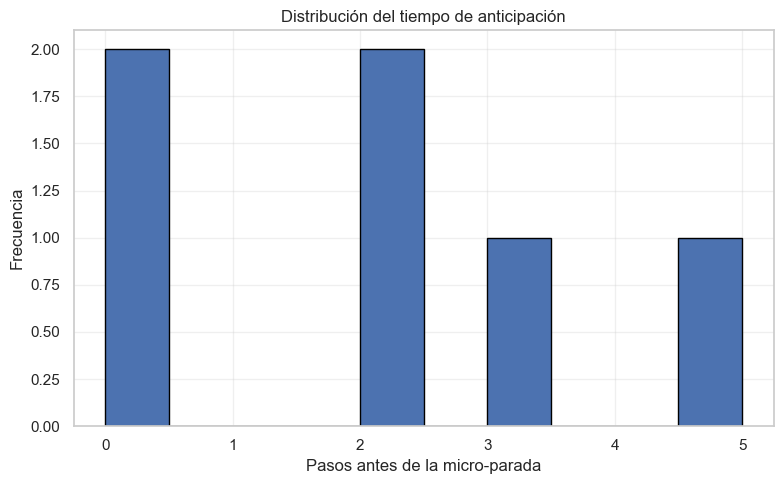

In [15]:
plt.figure(figsize=(8, 5))

if len(anticipaciones) > 0:
    plt.hist(anticipaciones, bins=10, edgecolor="black")
    plt.title("Distribución del tiempo de anticipación")
    plt.xlabel("Pasos antes de la micro-parada")
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
else:
    plt.text(
        0.5,
        0.5,
        "No hubo anticipaciones detectadas",
        ha="center",
        va="center"
    )
    plt.title("Distribución del tiempo de anticipación")
    plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_histograma_anticipacion.png", dpi=300, bbox_inches="tight")
plt.show()

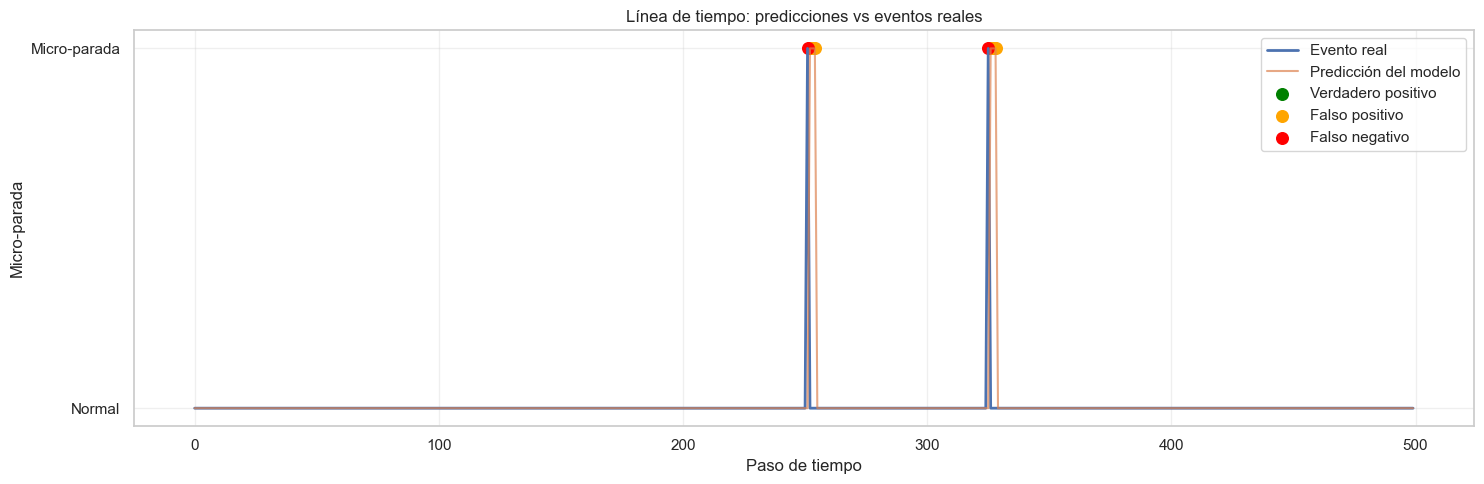

In [16]:
inicio = 0
fin = 500

y_real_segmento = y_test_detect[inicio:fin]
y_pred_segmento = pred_det[inicio:fin]

pasos = np.arange(inicio, fin)

tp = (y_real_segmento == 1) & (y_pred_segmento == 1)
fp = (y_real_segmento == 0) & (y_pred_segmento == 1)
fn = (y_real_segmento == 1) & (y_pred_segmento == 0)

plt.figure(figsize=(15, 5))

plt.plot(pasos, y_real_segmento, label="Evento real", linewidth=2)
plt.plot(pasos, y_pred_segmento, label="Predicción del modelo", alpha=0.7)

plt.scatter(pasos[tp], y_real_segmento[tp], color="green", label="Verdadero positivo", s=70)
plt.scatter(pasos[fp], y_pred_segmento[fp], color="orange", label="Falso positivo", s=70)
plt.scatter(pasos[fn], y_real_segmento[fn], color="red", label="Falso negativo", s=70)

plt.title("Línea de tiempo: predicciones vs eventos reales")
plt.xlabel("Paso de tiempo")
plt.ylabel("Micro-parada")
plt.yticks([0, 1], ["Normal", "Micro-parada"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_linea_tiempo.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Parámetro ajustable:
# En este dataset sintético, la micro-parada se simula durante aproximadamente 3 pasos.
DOWNTIME_BASE_PROMEDIO = 3

micro_paradas_totales = int(y_test_detect.sum())
micro_paradas_detectadas = len(anticipaciones)

tiempo_anticipacion_promedio = anticipaciones.mean() if len(anticipaciones) > 0 else 0

downtime_total = micro_paradas_totales * DOWNTIME_BASE_PROMEDIO
downtime_reducido = micro_paradas_detectadas * tiempo_anticipacion_promedio

# Evitar que el downtime reducido sea mayor al downtime total
downtime_reducido = min(downtime_reducido, downtime_total)

downtime_con_sistema = downtime_total - downtime_reducido

porcentaje_reduccion = (
    downtime_reducido / downtime_total * 100
    if downtime_total > 0 else 0
)

impacto = pd.DataFrame({
    "Escenario": ["Sin sistema", "Con sistema"],
    "Downtime estimado": [downtime_total, downtime_con_sistema]
})

print("Micro-paradas totales:", micro_paradas_totales)
print("Micro-paradas detectadas con anticipación:", micro_paradas_detectadas)
print("Anticipación promedio:", round(tiempo_anticipacion_promedio, 2), "pasos")
print("Downtime total sin sistema:", round(downtime_total, 2))
print("Downtime reducido:", round(downtime_reducido, 2))
print(f"Reducción estimada: {porcentaje_reduccion:.2f}%")

impacto

Micro-paradas totales: 8
Micro-paradas detectadas con anticipación: 6
Anticipación promedio: 2.0 pasos
Downtime total sin sistema: 24
Downtime reducido: 12.0
Reducción estimada: 50.00%


,Escenario,Downtime estimado
0,Sin sistema,24.0
1,Con sistema,12.0


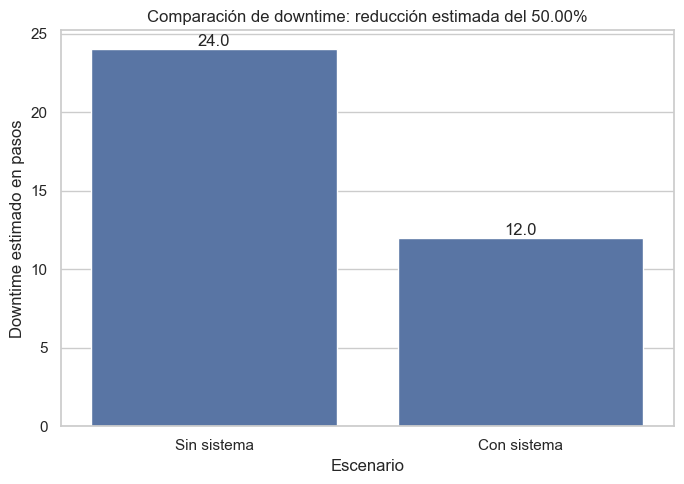

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=impacto,
    x="Escenario",
    y="Downtime estimado"
)

plt.title(f"Comparación de downtime: reducción estimada del {porcentaje_reduccion:.2f}%")
plt.xlabel("Escenario")
plt.ylabel("Downtime estimado en pasos")

for i, valor in enumerate(impacto["Downtime estimado"]):
    plt.text(i, valor, f"{valor:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_simulacion_impacto.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusión

Las visualizaciones permiten evaluar el desempeño del modelo de detección de micro-paradas.  
La matriz de confusión muestra los aciertos y errores en la detección binaria, mientras que la matriz por causa permite analizar qué tan bien se identifican los tipos de falla.

La curva ROC permite observar la capacidad del modelo para separar condiciones normales de micro-paradas.  
Además, el histograma de anticipación muestra cuántos pasos antes se logró detectar una micro-parada.

Finalmente, la simulación de impacto compara el downtime estimado sin sistema y con sistema.  
Esto permite estimar el beneficio operativo del modelo al anticipar eventos y reducir el tiempo perdido por micro-paradas.

In [19]:
print("===== VERIFICACIÓN FINAL =====")

errores = []

# Verificar dataset
try:
    print("Dataset:", df.shape)
    if df.empty:
        errores.append("El dataset está vacío.")
except NameError:
    errores.append("No existe la variable df.")

print("\t")

# Verificar ventanas
try:
    print("X_test:", X_test.shape)
    print("y_test_detect:", y_test_detect.shape)
    if len(X_test) == 0:
        errores.append("X_test está vacío.")
except NameError:
    errores.append("No existen X_test o y_test_detect.")

print("\t")

# Verificar predicciones
try:
    print("Predicciones binarias:", pred_det.shape)
    print("Probabilidades:", probs_det.shape)
    if len(pred_det) != len(y_test_detect):
        errores.append("pred_det y y_test_detect no tienen el mismo tamaño.")
except NameError:
    errores.append("No existen pred_det o probs_det.")

print("\t")

# Verificar valores de predicción
try:
    valores_pred = set(np.unique(pred_det))
    print("Valores en pred_det:", valores_pred)
    if not valores_pred.issubset({0, 1}):
        errores.append("pred_det tiene valores diferentes de 0 y 1.")
except:
    errores.append("No se pudieron verificar los valores de pred_det.")

print("\t")

# Verificar matriz de confusión
try:
    print("Matriz binaria:")
    print(cm_det)
    if cm_det.shape != (2, 2):
        errores.append("La matriz de confusión binaria no es de 2x2.")
except NameError:
    errores.append("No existe cm_det.")

print("\t")

# Verificar ROC
try:
    print("AUC:", roc_auc)
    if roc_auc < 0 or roc_auc > 1:
        errores.append("El AUC está fuera del rango 0 a 1.")
except NameError:
    errores.append("No existe roc_auc.")

print("\t")

# Verificar impacto
try:
    print("Tabla de impacto:")
    display(impacto)
    if "Sin sistema" not in impacto["Escenario"].values:
        errores.append("Falta el escenario Sin sistema.")
    if "Con sistema" not in impacto["Escenario"].values:
        errores.append("Falta el escenario Con sistema.")
except NameError:
    errores.append("No existe la tabla impacto.")

print("\n===== RESULTADO =====")

if len(errores) == 0:
    print("Todo parece estar bien.")
else:
    print("Hay detalles por corregir:")
    for error in errores:
        print("-", error)

===== VERIFICACIÓN FINAL =====
Dataset: (20000, 6)
	
X_test: (2997, 20, 4)
y_test_detect: (2997,)
	
Predicciones binarias: (2997,)
Probabilidades: (2997,)
	
Valores en pred_det: {np.int64(0), np.int64(1)}
	
Matriz binaria:
[[2950   39]
 [   2    6]]
	
AUC: 0.8976246236199398
	
Tabla de impacto:


,Escenario,Downtime estimado
0,Sin sistema,24.0
1,Con sistema,12.0



===== RESULTADO =====
Todo parece estar bien.
